In [1]:
# 1. 파이썬 코드에서 Matplotlib 폰트 설정
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from datetime import timedelta
from itertools import combinations
from collections import Counter

# 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정이 완료되었습니다.")

# 3. 데이터 로드 및 통합 (모든 문제 풀이의 시작점)
try:
    orders_df = pd.read_csv('../data/orders.csv')
    payments_df = pd.read_csv('../data/payments.csv')
    products_df = pd.read_csv('../data/products.csv')
    shipping_df = pd.read_csv('../data/shipping.csv')
    customers_df = pd.read_csv('../data/customers.csv')

    # 모든 데이터프레임 병합
    df = pd.merge(orders_df, payments_df, on='order_id', how='left')
    df = pd.merge(df, products_df, on='product_id', how='left')
    df = pd.merge(df, customers_df, on='customer_id', how='left')
    df = pd.merge(df, shipping_df, on='order_id', how='left')

    # 데이터 전처리
    date_cols = ['order_date', 'payment_date', 'join_date', 'shipping_start_date', 'shipping_end_date']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    df['total_sales'] = df['quantity'] * df['price']
    
    print("데이터 로드 및 통합이 완료되었습니다.")

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")

한글 폰트 설정이 완료되었습니다.
데이터 로드 및 통합이 완료되었습니다.


In [2]:
# 문제 1: 시간대별 주문량 추이를 분석하여 피크 타임을 찾고, 요일별로 패턴에 차이가 있는지 확인하세요
# 시각화: 히트맵

# 비즈니스 목적: 서버 리소스 할당, 인력 배치, 타임 세일 이벤트 기획 등 운영 최적화에 활용합니다

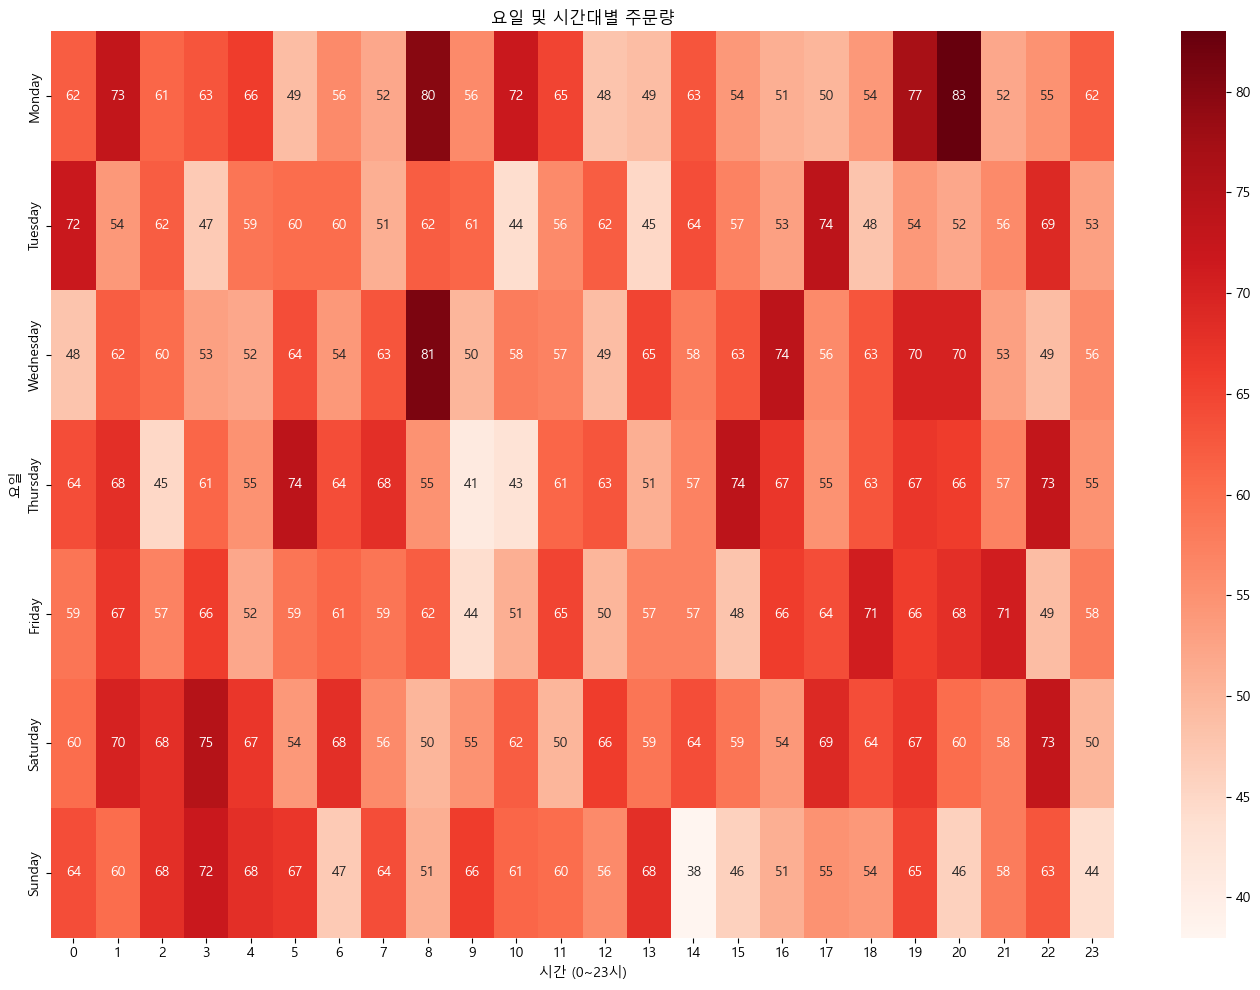

In [65]:
# 데이터 전처리
cols = ['customer_id','order_date']
df_data1 = df[cols].copy()

df_data1['weekday'] = df_data1['order_date'].dt.dayofweek

df_data1['times'] = df_data1['order_date'].dt.hour

time_cnt = df_data1.groupby(['times','weekday']).agg(cnt=('customer_id','count')).reset_index()

heatmap_data = time_cnt.pivot(index='weekday', columns='times', values='cnt')
weekday_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 히트맵 시각화
plt.figure(figsize=(14, 10))

sns.heatmap(heatmap_data, 
            annot=True,           # 숫자 표시
            cmap='Reds',        # 색상 팔레트
            )

# 축 레이블 설정
plt.ylabel('요일')
plt.xlabel('시간 (0~23시)')
plt.title('요일 및 시간대별 주문량')

# x축 요일 라벨 변경
plt.yticks(ticks=np.arange(7) + 0.5, labels=weekday_labels)

plt.tight_layout()
plt.show()

In [ ]:
# 문제 2: 월별 주문 건수와 평균 주문액(AOV)의 변화 추이를 함께 시각화하여 분석하세요.
# 시각화: 이중 축 차트

# 비즈니스 목적: 비즈니스의 